# Binomial Distribution — Practical Demo

In this notebook, we will use Python to:

- Calculate Binomial probabilities
- Verify the Binomial PMF
- Solve practical examples
- Visualize a Binomial probability distribution
- Observe how changing \(p\) changes the distribution

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

## Binomial PMF

The probability of obtaining exactly \(k\) successes in \(n\) independent trials is:

\[
P(X=k)=\binom{n}{k}p^k(1-p)^{n-k}
\]

The binomial coefficient is:

\[
\binom{n}{k}=\frac{n!}{k!(n-k)!}
\]

In [2]:
def binomial_pmf(n, k, p):
    """
    Calculate P(X = k) for a Binomial Distribution.
    """
    if not 0 <= p <= 1:
        raise ValueError("Probability p must be between 0 and 1.")

    if not 0 <= k <= n:
        return 0.0

    coefficient = math.comb(n, k)

    return coefficient * (p ** k) * ((1 - p) ** (n - k))

In [3]:
# Example: 5 coin tosses, exactly 3 heads

n = 5
k = 3
p = 0.5

probability = binomial_pmf(n, k, p)

print(f"P(X = {k}) = {probability:.4f}")
print(f"Percentage = {probability * 100:.2f}%")

P(X = 3) = 0.3125
Percentage = 31.25%


## Quality Control Example

A factory produces products with a \(10\%\) probability of being defective.

Suppose 10 products are inspected.

Find the probability of exactly 2 defective products.

Parameters:

\[
n=10,\qquad p=0.1,\qquad k=2
\]

In [4]:
n = 10
k = 2
p = 0.1

probability = binomial_pmf(n, k, p)

print(f"P(X = {k}) = {probability:.4f}")
print(f"Percentage = {probability * 100:.2f}%")

P(X = 2) = 0.1937
Percentage = 19.37%


## Binomial Distribution

Instead of calculating the probability of only one value of \(X\), we can calculate the probability for every possible number of successes.

For \(n\) trials:

\[
X\in\{0,1,\ldots,n\}
\]

In [5]:
n = 10
p = 0.5

k_values = np.arange(0, n + 1)
probabilities = np.array([
    binomial_pmf(n, k, p)
    for k in k_values
])

for k, probability in zip(k_values, probabilities):
    print(f"P(X = {k}) = {probability:.4f}")

P(X = 0) = 0.0010
P(X = 1) = 0.0098
P(X = 2) = 0.0439
P(X = 3) = 0.1172
P(X = 4) = 0.2051
P(X = 5) = 0.2461
P(X = 6) = 0.2051
P(X = 7) = 0.1172
P(X = 8) = 0.0439
P(X = 9) = 0.0098
P(X = 10) = 0.0010


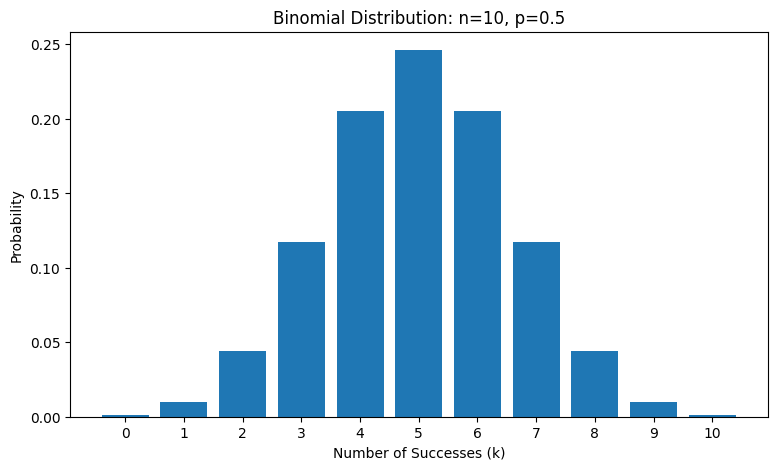

In [6]:
plt.figure(figsize=(9, 5))

plt.bar(k_values, probabilities)

plt.xlabel("Number of Successes (k)")
plt.ylabel("Probability")
plt.title("Binomial Distribution: n=10, p=0.5")
plt.xticks(k_values)

plt.show()

## Checking That the Probabilities Sum to 1

A valid probability distribution must satisfy:

\[
\sum_{k=0}^{n}P(X=k)=1
\]

In [7]:
total_probability = probabilities.sum()

print(f"Total probability = {total_probability:.4f}")

Total probability = 1.0000


## Mean, Variance, and Standard Deviation

For a Binomial Distribution:

\[
\mu=np
\]

\[
\sigma^2=np(1-p)
\]

\[
\sigma=\sqrt{np(1-p)}
\]

In [8]:
n = 10
p = 0.5

mean = n * p
variance = n * p * (1 - p)
std_dev = math.sqrt(variance)

print(f"Mean = {mean}")
print(f"Variance = {variance}")
print(f"Standard Deviation = {std_dev:.4f}")

Mean = 5.0
Variance = 2.5
Standard Deviation = 1.5811


## Effect of Probability of Success

The shape of a Binomial Distribution changes when the probability of success \(p\) changes.

We will compare:

- \(p=0.2\)
- \(p=0.5\)
- \(p=0.8\)

while keeping the number of trials fixed at:

\[
n=10
\]

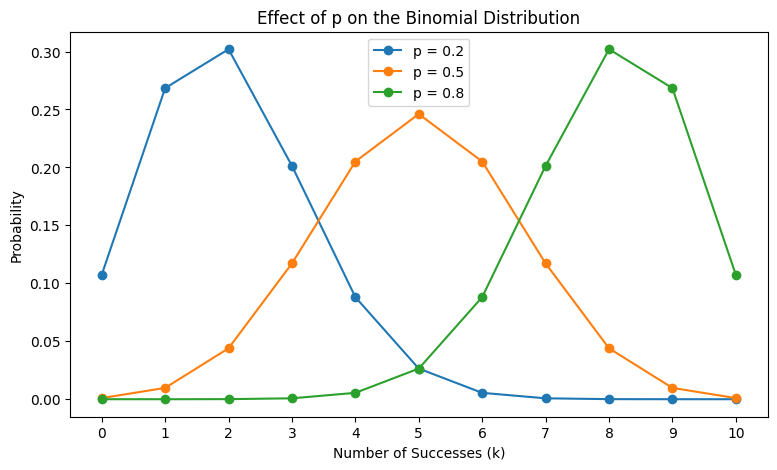

In [9]:
n = 10
probabilities_p = [0.2, 0.5, 0.8]

plt.figure(figsize=(9, 5))

for p in probabilities_p:
    probabilities = [
        binomial_pmf(n, k, p)
        for k in k_values
    ]

    plt.plot(
        k_values,
        probabilities,
        marker="o",
        label=f"p = {p}"
    )

plt.xlabel("Number of Successes (k)")
plt.ylabel("Probability")
plt.title("Effect of p on the Binomial Distribution")
plt.xticks(k_values)
plt.legend()

plt.show()

## Bernoulli as a Special Case of Binomial

A Bernoulli Distribution represents one trial.

Therefore, a Bernoulli Distribution can be viewed as a Binomial Distribution with:

\[
n=1
\]

For example:

\[
X\sim\operatorname{Binomial}(1,p)
\]

has only two possible values:

\[
X\in\{0,1\}
\]

This demonstrates the relationship:

\[
\boxed{\text{Bernoulli} = \text{Binomial with }n=1}
\]

In [10]:
p = 0.7
n = 1

for k in [0, 1]:
    probability = binomial_pmf(n, k, p)
    print(f"P(X = {k}) = {probability:.2f}")

P(X = 0) = 0.30
P(X = 1) = 0.70


## Summary

The Binomial Distribution is useful when we have:

1. A fixed number of trials
2. Two possible outcomes per trial
3. Independent trials
4. A constant probability of success

The main formula is:

\[
P(X=k)=\binom{n}{k}p^k(1-p)^{n-k}
\]

The main descriptive statistics are:

\[
\mu=np
\]

\[
\sigma^2=np(1-p)
\]

\[
\sigma=\sqrt{np(1-p)}
\]